
# Question 1: DDPM on FashionMNIST

This notebook guides you through the DDPM part of Assignment 3. You will implement the forward-process utilities, reverse-process utilities, and sampling helpers needed to train a denoising diffusion model on FashionMNIST with a provided U-Net backbone.

Primary reference: [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) by Ho et al. (2020).

Edit these files before running the smoke test and training sections:
- `q1_ddpm.py`
- `q1_trainer_ddpm.py`

Provided support files:
- `ddpm_utils/`
- `images/`
- `requirements.txt`

Recommended Colab workflow:
1. Download `assignment3_release.zip`, unzip it on your computer first, and upload the extracted `assignment3_release/` folder to Google Drive. Do not upload the zip file to Drive.
2. Open the notebook from that Drive folder, mount Drive, and run the setup cells below.
3. Complete the TODOs in the two Python files above.
4. Re-run the notebook from the top.



## Colab setup

Recommended workflow for Colab:
1. Download `assignment3_release.zip`, unzip it on your computer first, and upload the extracted `assignment3_release/` folder to Google Drive. Do not upload the zip file to Drive.
2. Open the notebook from Google Drive in Colab and mount Drive.
3. Run the next setup cell to locate the extracted release folder.
4. Finish the TODOs in `q1_ddpm.py` and `q1_trainer_ddpm.py`.
5. Re-run the notebook from the top before training.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

In [2]:

import os
import sys
from pathlib import Path


def _candidate_roots(cwd: Path):
    candidates = [
        Path('/content/drive/MyDrive/assignment3_release'),
        Path('/content/assignment3_release'),
        cwd,
    ]
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / 'assignment3_release')
    return candidates


def _is_project_root(path: Path, marker: str) -> bool:
    return path.is_dir() and (path / marker).exists()


def find_project_root(marker: str) -> Path:
    cwd = Path.cwd().resolve()
    seen_roots = set()
    for candidate in _candidate_roots(cwd):
        candidate = candidate.expanduser().resolve()
        if candidate in seen_roots:
            continue
        seen_roots.add(candidate)
        if _is_project_root(candidate, marker):
            return candidate

    raise FileNotFoundError(
        'Could not locate the Assignment 3 release folder. '
        'Unzip assignment3_release.zip on your computer first, upload the extracted assignment3_release folder to Google Drive, and do not upload the zip file itself. '
        'open the notebook from that folder, and rerun this cell.'
    )


PROJECT_ROOT = find_project_root('q1_ddpm.py')
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\guill\GitHub\IFT6135-Assignments\assignment-3


In [3]:
import importlib
import subprocess
import sys

for package in ["easydict"]:
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


## Imports and configuration

Q1 keeps the model backbone fixed so the main focus is the DDPM math and sampling procedure.

Key ideas to keep in mind:
- the forward process gradually adds Gaussian noise over `T = 1000` steps
- the U-Net predicts the noise term `eps_theta(x_t, t)`
- training minimizes the simplified denoising loss

The main DDPM equations used throughout Q1 are:

$$q(x_t \mid x_0) = \mathcal{N}(x_t; \sqrt{\bar\alpha_t}x_0, (1-\bar\alpha_t)I)$$

$$x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t, t)\right)$$

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{x_0, \epsilon, t}\left[\lVert \epsilon - \epsilon_\theta(x_t, t) \rVert_2^2\right]$$


<img src="https://github.com/JingYue2000/HW_Supporting_materials/blob/main/diffusion_model.png?raw=true" width=500px>
*Figure: The forward diffusion process gradually adds Gaussian noise to a clean image $\mathbf{x}_0$, while the reverse process learns to denoise step by step.*


### Preview `q1_ddpm.py`

Open this file, complete the TODOs, and then rerun the import cells below.


In [4]:

print((PROJECT_ROOT / "q1_ddpm.py").read_text())


# Guillaume Genois, 20248507
# April 28, 2026

from typing import Optional, Tuple

import torch
from torch import nn


class DenoiseDiffusion:
    def __init__(self, eps_model: nn.Module, n_steps: int, device: torch.device):
        super().__init__()
        self.eps_model = eps_model
        self.beta = torch.linspace(0.0001, 0.02, n_steps).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)
        self.n_steps = n_steps
        self.sigma2 = self.beta

    def gather(self, c: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        c_ = c.gather(-1, t)
        return c_.reshape(-1, 1, 1, 1)

    def q_xt_x0(self, x0: torch.Tensor, t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # STUDENT TODO START
        # q(x_t | x_0): return the closed-form mean and variance.
        # x0 shape: (batch_size, channels, height, width)
        # t shape: (batch_size,)
        # return shapes: both should broadcast correctly with x


### Preview `q1_trainer_ddpm.py`

You will complete the reverse-sampling helpers in this file. Rerun the notebook after editing it.


In [5]:

print((PROJECT_ROOT / "q1_trainer_ddpm.py").read_text())


# Guillaume Genois, 20248507
# April 28, 2026

import copy
import os

import torch
from matplotlib import pyplot as plt
from torch.amp import GradScaler, autocast
from tqdm import tqdm

from ddpm_utils.args import args


torch.manual_seed(42)


def one_param(m):
    return next(iter(m.parameters()))


class EMA:
    def __init__(self, beta):
        super().__init__()
        self.beta = beta
        self.step = 0

    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            old_weight, up_weight = ma_params.data, current_params.data
            ma_params.data = self.update_average(old_weight, up_weight)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

    def step_ema(self, ema_model, model, step_start_ema=2000):
        if self.step < step_start_ema:
            self.reset_parameters


### Configuration

These defaults are chosen so the notebook matches the assignment setup described in the handout.


In [6]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.utils.data

from ddpm_utils.args import args
from ddpm_utils.dataset import FashionMNISTDataset
from ddpm_utils.unet import UNet, load_weights
from q1_ddpm import DenoiseDiffusion
from q1_trainer_ddpm import Trainer

In [7]:
args.project_root = str(PROJECT_ROOT)
args.MODEL_PATH = str(PROJECT_ROOT / "q1_ddpm_model.pkl")
args.ddpm_model_path = args.MODEL_PATH
args.device = "cuda" if torch.cuda.is_available() else "cpu"
args.fp16_precision = args.device == "cuda"
args.n_steps = 1000
args.epochs = 20
args.batch_size = 256
args.learning_rate = 2e-4
args.n_samples = 16
args.image_size = 32
print(args)

{'image_channels': 1, 'image_size': 32, 'n_steps': 1000, 'nb_save': 5, 'batch_size': 256, 'n_samples': 16, 'learning_rate': 0.0002, 'epochs': 20, 'device': 'cuda', 'fp16_precision': True, 'show_every_n_epochs': 2, 'save_every_n_epochs': 2, 'num_workers': 0, 'project_root': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3', 'ddpm_model_path': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3\\q1_ddpm_model.pkl', 'flow_model_path': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3\\q2_flow_matching_model.pkl', 'MODEL_PATH': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3\\q1_ddpm_model.pkl'}



## Student implementation checklist

Complete these functions before running the smoke test or training cells:
- `q1_ddpm.py`: `q_xt_x0`, `q_sample`, `p_xt_prev_xt`, `p_sample`, `loss`
- `q1_trainer_ddpm.py`: `Trainer.sample`, `Trainer.generate_intermediate_samples`

These TODOs map directly to the DDPM equations above:
- `q_xt_x0`: compute the mean and variance of $q(x_t \mid x_0)$.
- `q_sample`: use the reparameterization $x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon$.
- `p_xt_prev_xt`: compute the reverse-process Gaussian $p_\theta(x_{t-1} \mid x_t) = \mathcal{N}(\mu_\theta(x_t, t), \sigma_t^2 I)$.
- `p_sample`: draw one sample from that reverse Gaussian.
- `loss`: implement the simplified denoising objective $\mathcal{L}_{\text{simple}}$.
- `Trainer.sample` and `Trainer.generate_intermediate_samples`: iterate the reverse chain from $t=T-1$ down to $t=0$.

The notebook imports those files directly, so your edits in the Python files are the source of truth.


In [8]:
def plot_saved_epoch_samples(image_dir: Path):
    sample_paths = sorted(image_dir.glob("epoch_*_sample_*.png"))
    if not sample_paths:
        print("No saved DDPM sample grids found yet. Run the training cell first.")
        return

    cols = min(3, len(sample_paths))
    rows = math.ceil(len(sample_paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = [axes] if not hasattr(axes, "ravel") else axes.ravel().tolist()
    for ax, path in zip(axes, sample_paths):
        ax.imshow(plt.imread(path), cmap="gray")
        ax.set_title(path.name)
        ax.axis("off")
    for ax in axes[len(sample_paths):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_intermediate_samples(images, steps_to_show, n_samples):
    fig, axs = plt.subplots(n_samples, len(images), figsize=(3 * len(images), 3 * n_samples))
    if n_samples == 1:
        axs = axs[None, :]
    for sample_idx in range(n_samples):
        for step_idx, img in enumerate(images):
            axs[sample_idx, step_idx].imshow(img[sample_idx, 0], cmap="gray")
            if step_idx == 0:
                title = "start noise"
            else:
                title = f"step {steps_to_show[step_idx - 1]}"
            axs[sample_idx, step_idx].set_title(title, fontsize=9)
            axs[sample_idx, step_idx].axis("off")
    plt.tight_layout()
    plt.show()



## Build the model and dataloader

This section reuses the provided U-Net and prepares 32x32 FashionMNIST batches. If you edit one of the student files above, rerun the import cells before continuing.


In [9]:
eps_model = UNet(c_in=1, c_out=1)
if Path(args.MODEL_PATH).exists():
    eps_model = load_weights(eps_model, args.MODEL_PATH)

diffusion_model = DenoiseDiffusion(eps_model=eps_model, n_steps=args.n_steps, device=args.device)
trainer = Trainer(args, eps_model, diffusion_model)

dataloader = torch.utils.data.DataLoader(
    FashionMNISTDataset(root=str(PROJECT_ROOT)),
    batch_size=args.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=args.num_workers,
    pin_memory=args.device == "cuda",
)
print(f"Using {args.device} with {len(dataloader)} batches per epoch.")

100%|██████████| 26.4M/26.4M [00:13<00:00, 1.89MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 277kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.40MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 1.60MB/s]

Using cuda with 234 batches per epoch.



## Smoke test

Before you launch training, finish `q1_ddpm.py` and `q1_trainer_ddpm.py`, rerun the import cells, and then use this small batch to confirm that the loss executes without errors.


In [10]:
x0 = next(iter(dataloader))[:8].to(args.device)
loss = diffusion_model.loss(x0, set_seed=True)
print(f"Smoke-test loss: {loss.item():.4f}")

Smoke-test loss: 1567.4874



## Train the DDPM

Run this cell only after the TODOs are implemented and the smoke test succeeds. The trainer periodically saves sample grids into `images/`.


100%|█████████▉| 995/1000 [00:10<00:00, 96.16it/s] 

Showing/saving samples from epoch 0


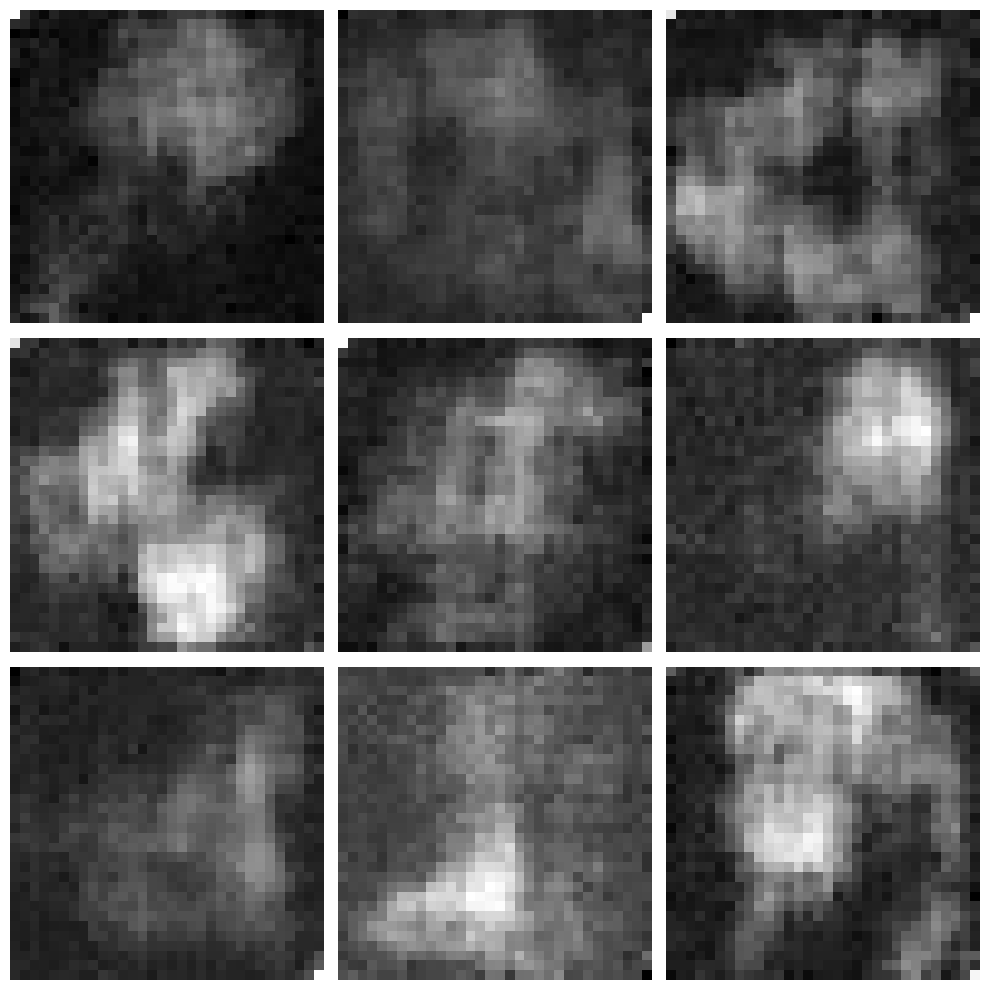

100%|█████████▉| 997/1000 [00:10<00:00, 98.03it/s] 

Showing/saving samples from epoch 2


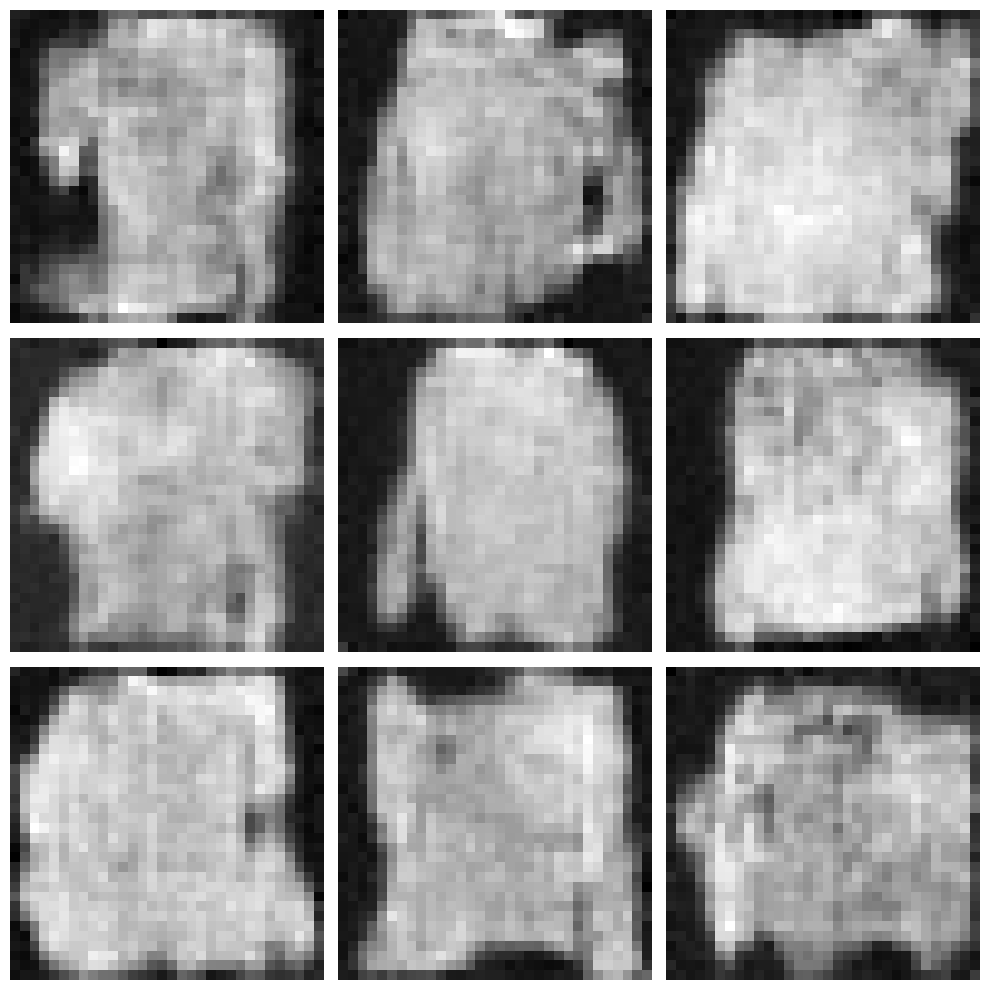

 99%|█████████▉| 990/1000 [00:10<00:00, 96.41it/s] 

Showing/saving samples from epoch 4


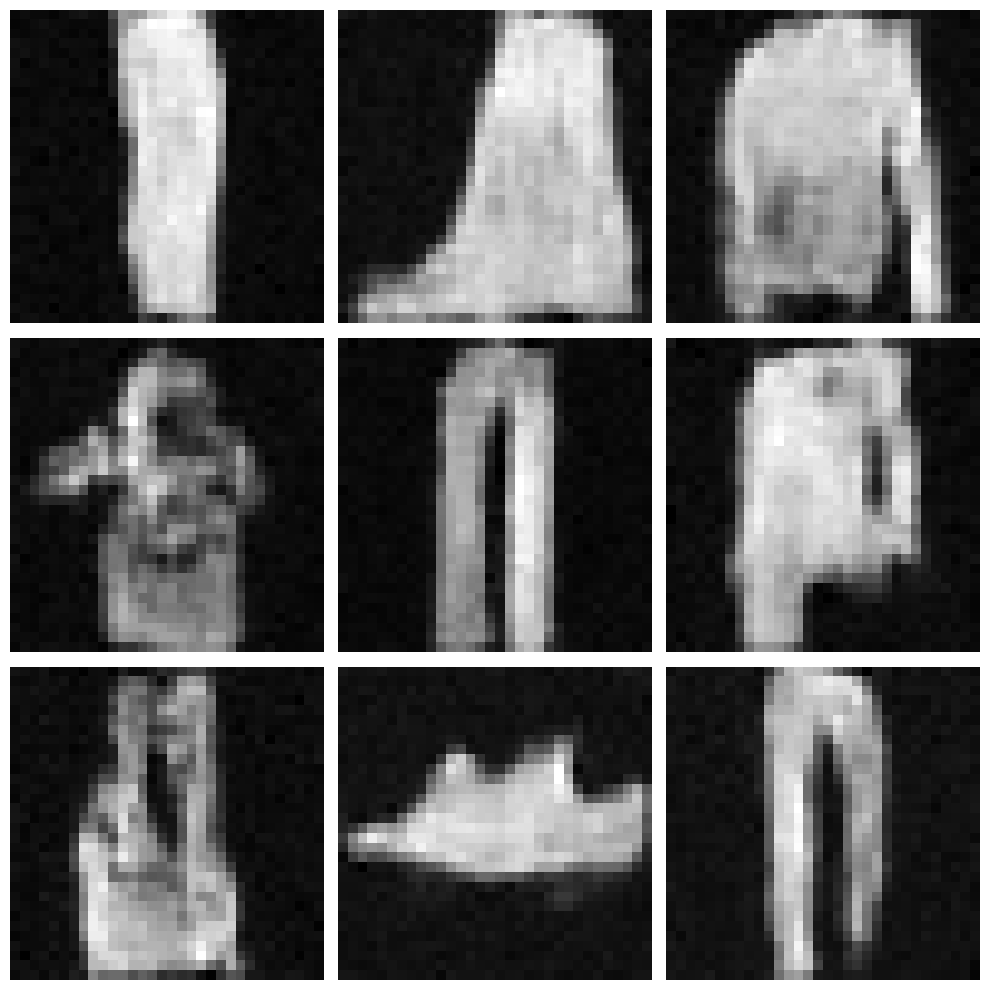

 99%|█████████▉| 994/1000 [00:10<00:00, 98.25it/s] 

Showing/saving samples from epoch 6


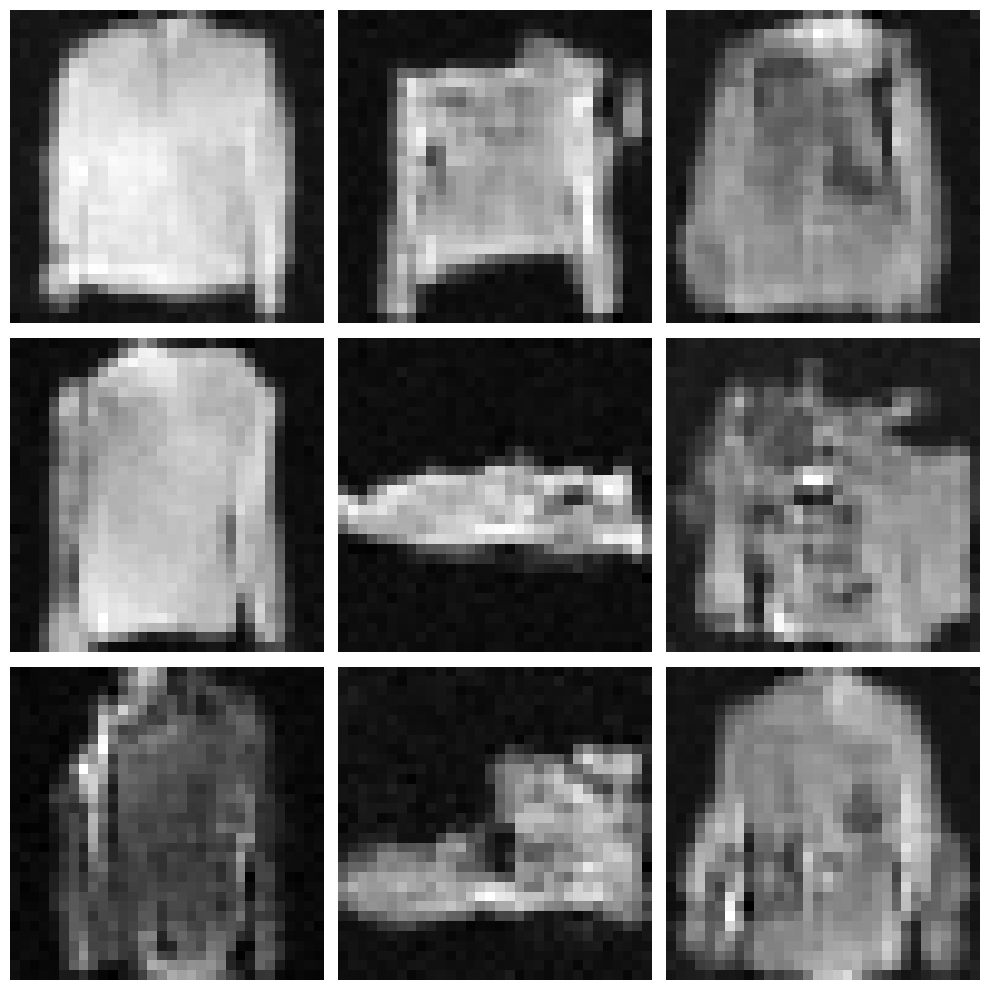

 99%|█████████▉| 988/1000 [00:09<00:00, 98.31it/s] 

Showing/saving samples from epoch 8


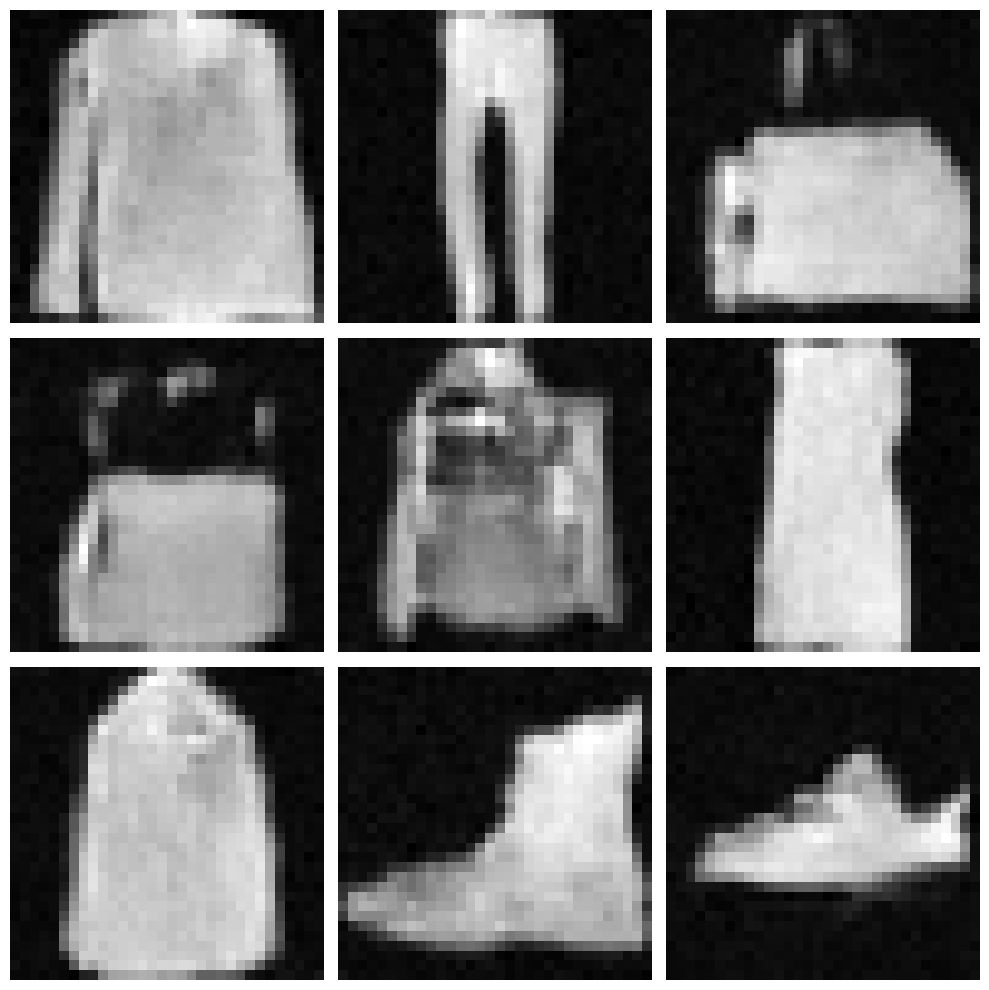

 99%|█████████▉| 993/1000 [00:09<00:00, 105.10it/s]

Showing/saving samples from epoch 10


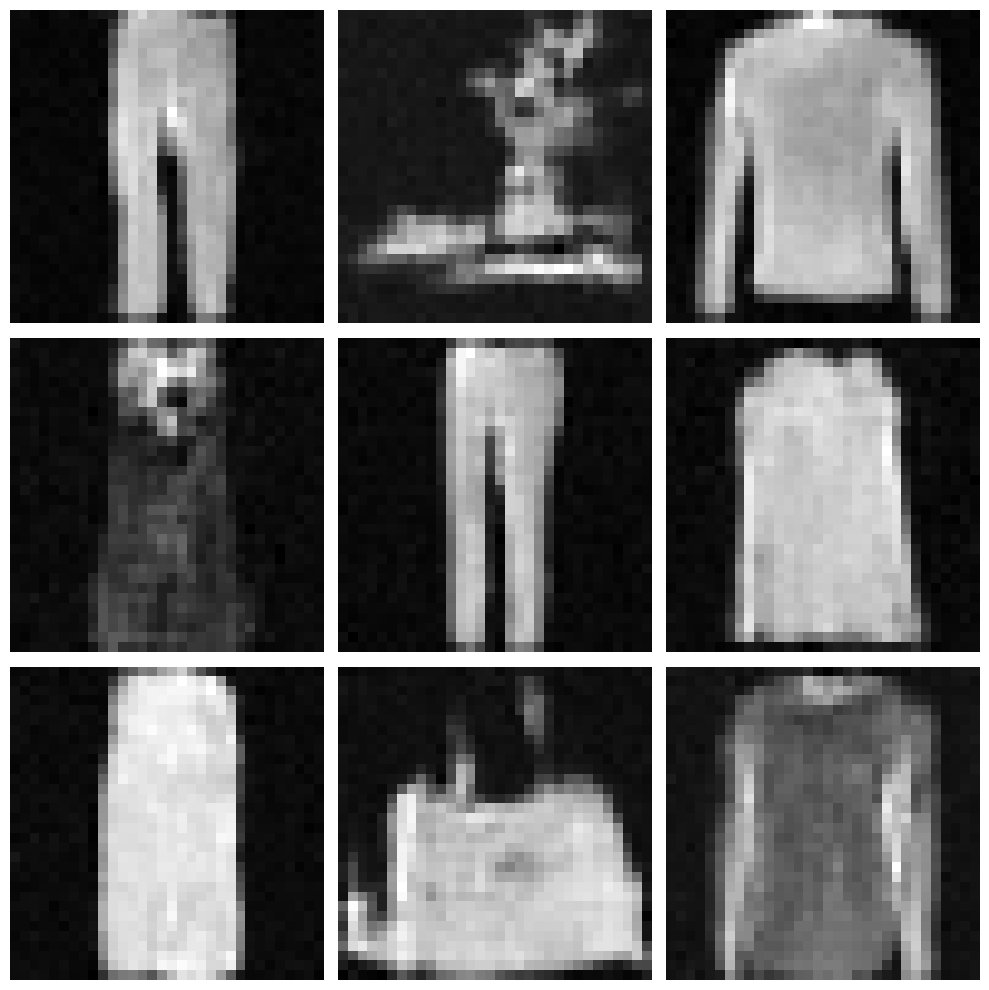

 99%|█████████▉| 990/1000 [00:09<00:00, 102.61it/s]

Showing/saving samples from epoch 12


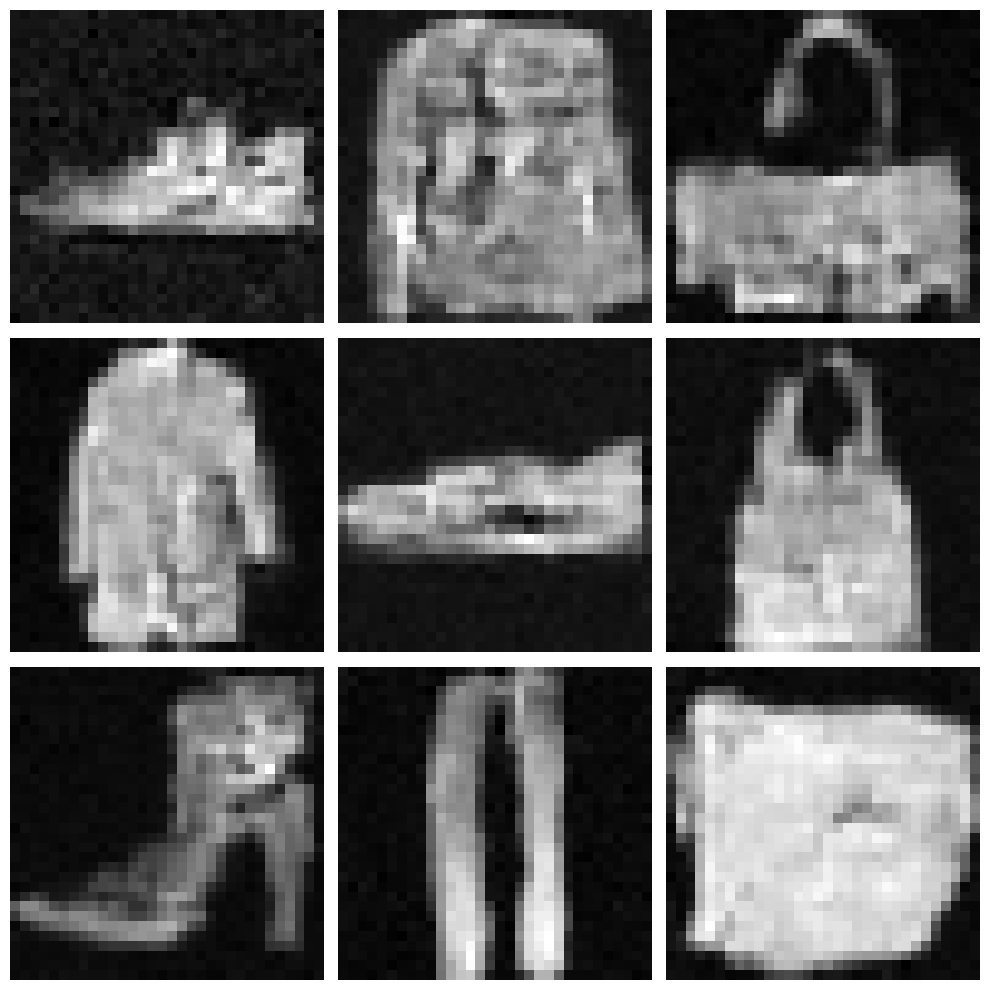

100%|█████████▉| 998/1000 [00:09<00:00, 98.56it/s] 

Showing/saving samples from epoch 14


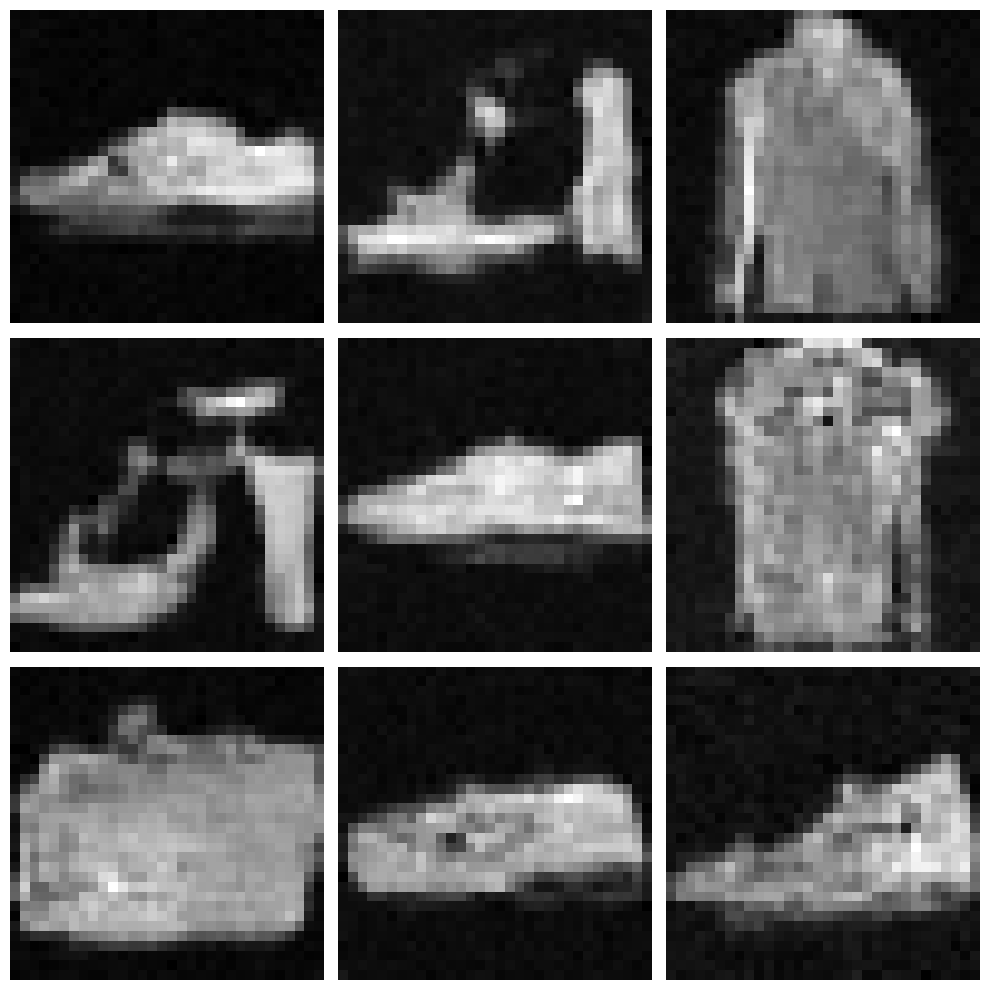

 99%|█████████▉| 991/1000 [00:10<00:00, 100.68it/s]

Showing/saving samples from epoch 16


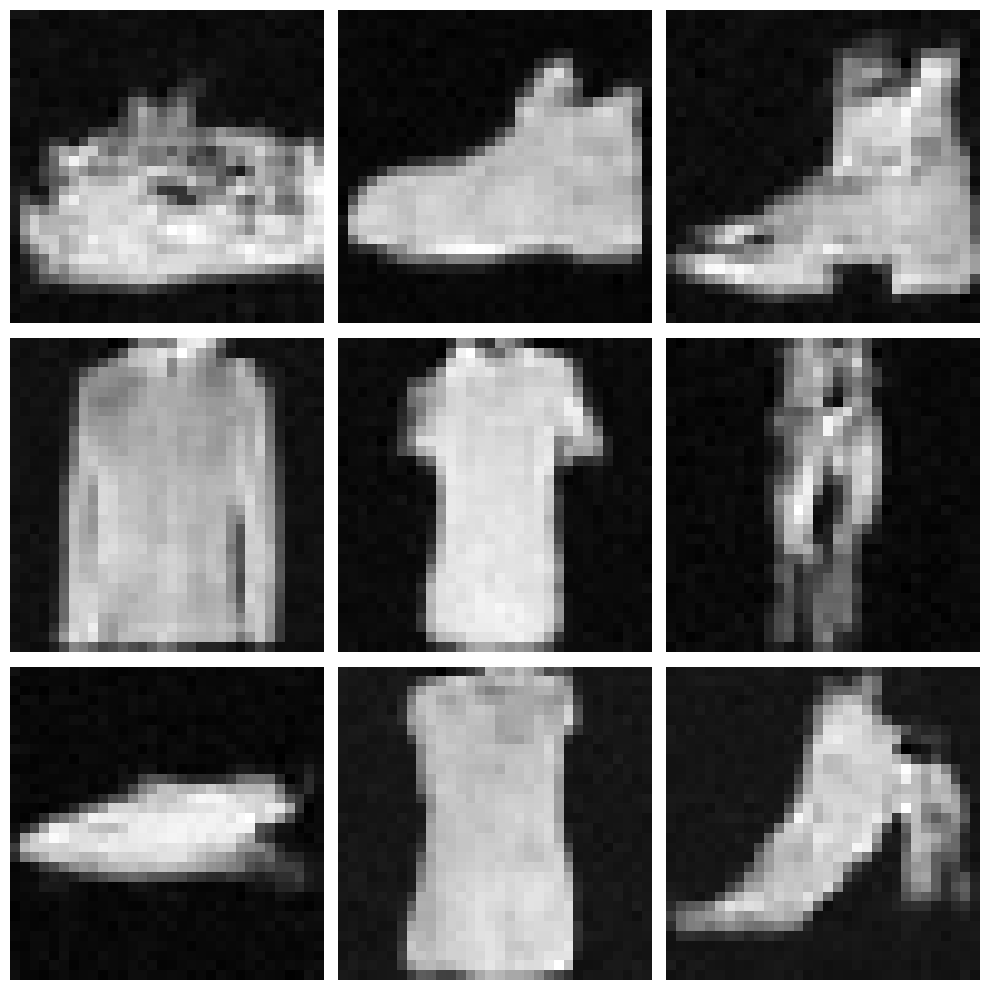

100%|█████████▉| 995/1000 [00:06<00:00, 240.89it/s]

Showing/saving samples from epoch 18


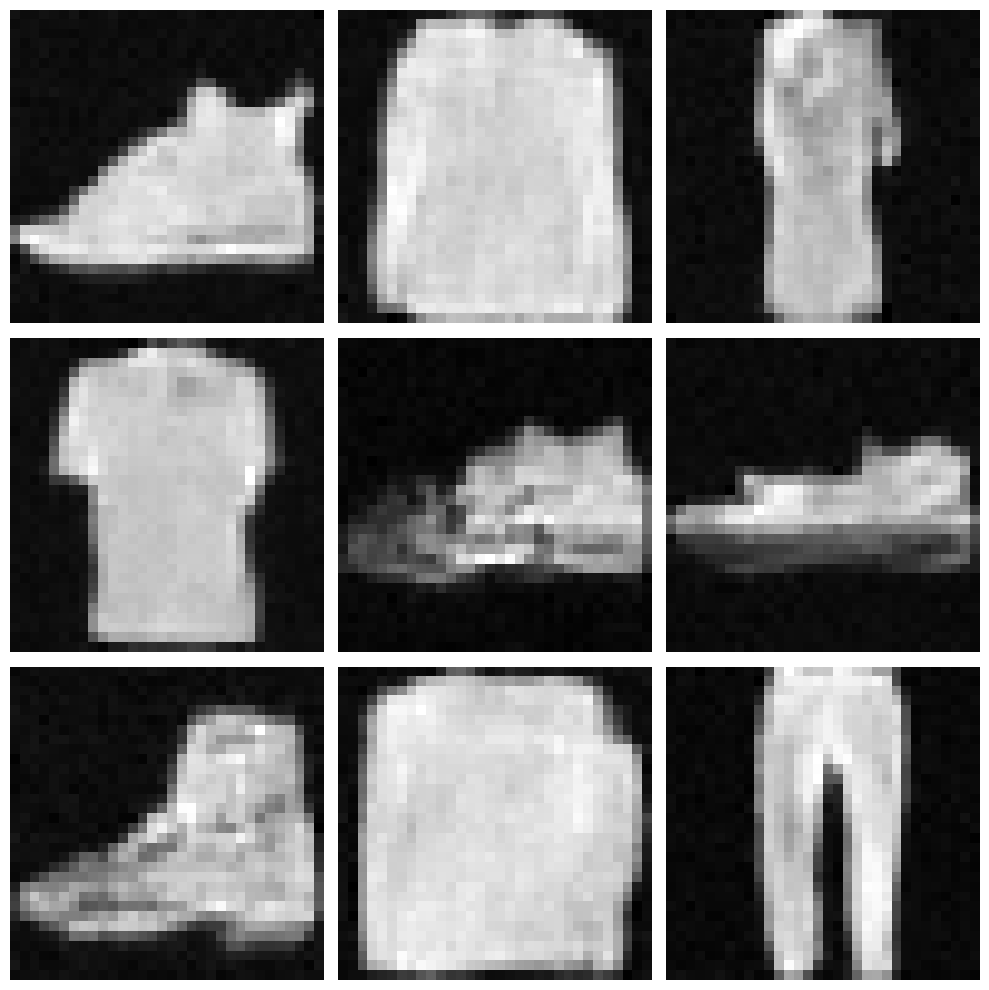

Epoch: 19/20 - lr: 2e-05 - Loss: 19.64: 100%|██████████| 234/234 [00:27<00:00,  8.39it/s]


In [11]:
trainer.train(dataloader)
trainer.save_model()



### Runtime expectations

On a Colab GPU, this training run is the main long step in Q1. Save your work in the Python files first, then let the notebook run through the full training and sampling workflow.



## Report question 8: training and sample quality

Use the saved sample grids to discuss:
- how image quality changes over training
- whether the samples become sharper and more class-consistent
- common artifacts or failure modes you observe
- practical changes that would likely improve the results


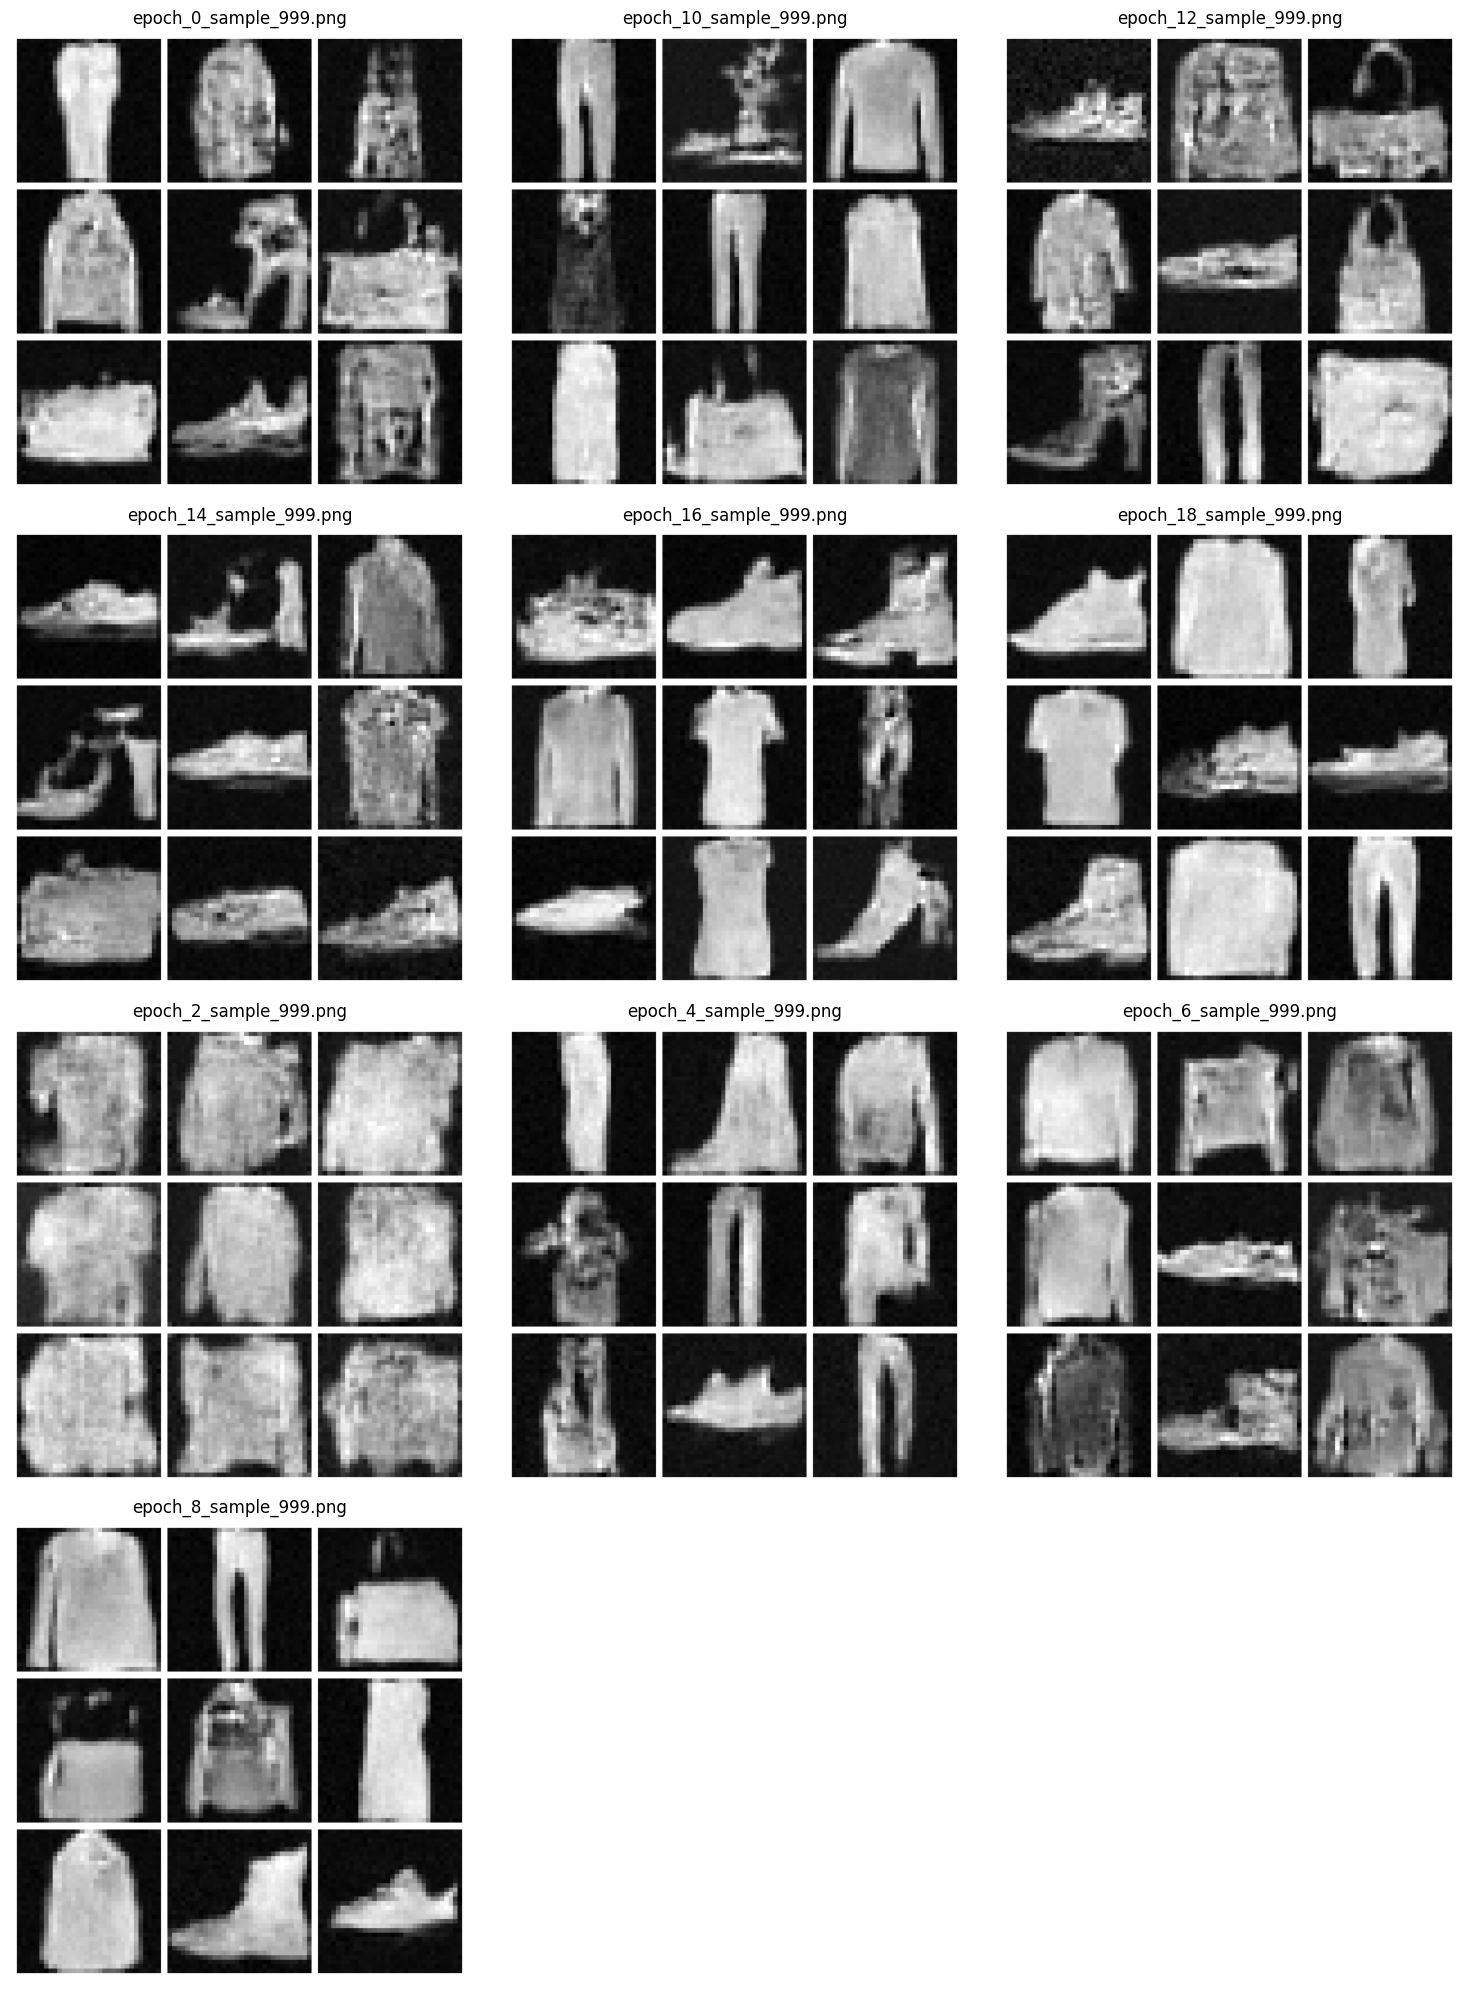

In [12]:
plot_saved_epoch_samples(PROJECT_ROOT / "images")


## Intermediate denoising visualization

This section traces a single reverse trajectory from pure noise to a recognizable image. It is useful both as a debugging check and as evidence for your report discussion.


100%|██████████| 1000/1000 [00:21<00:00, 47.15it/s]


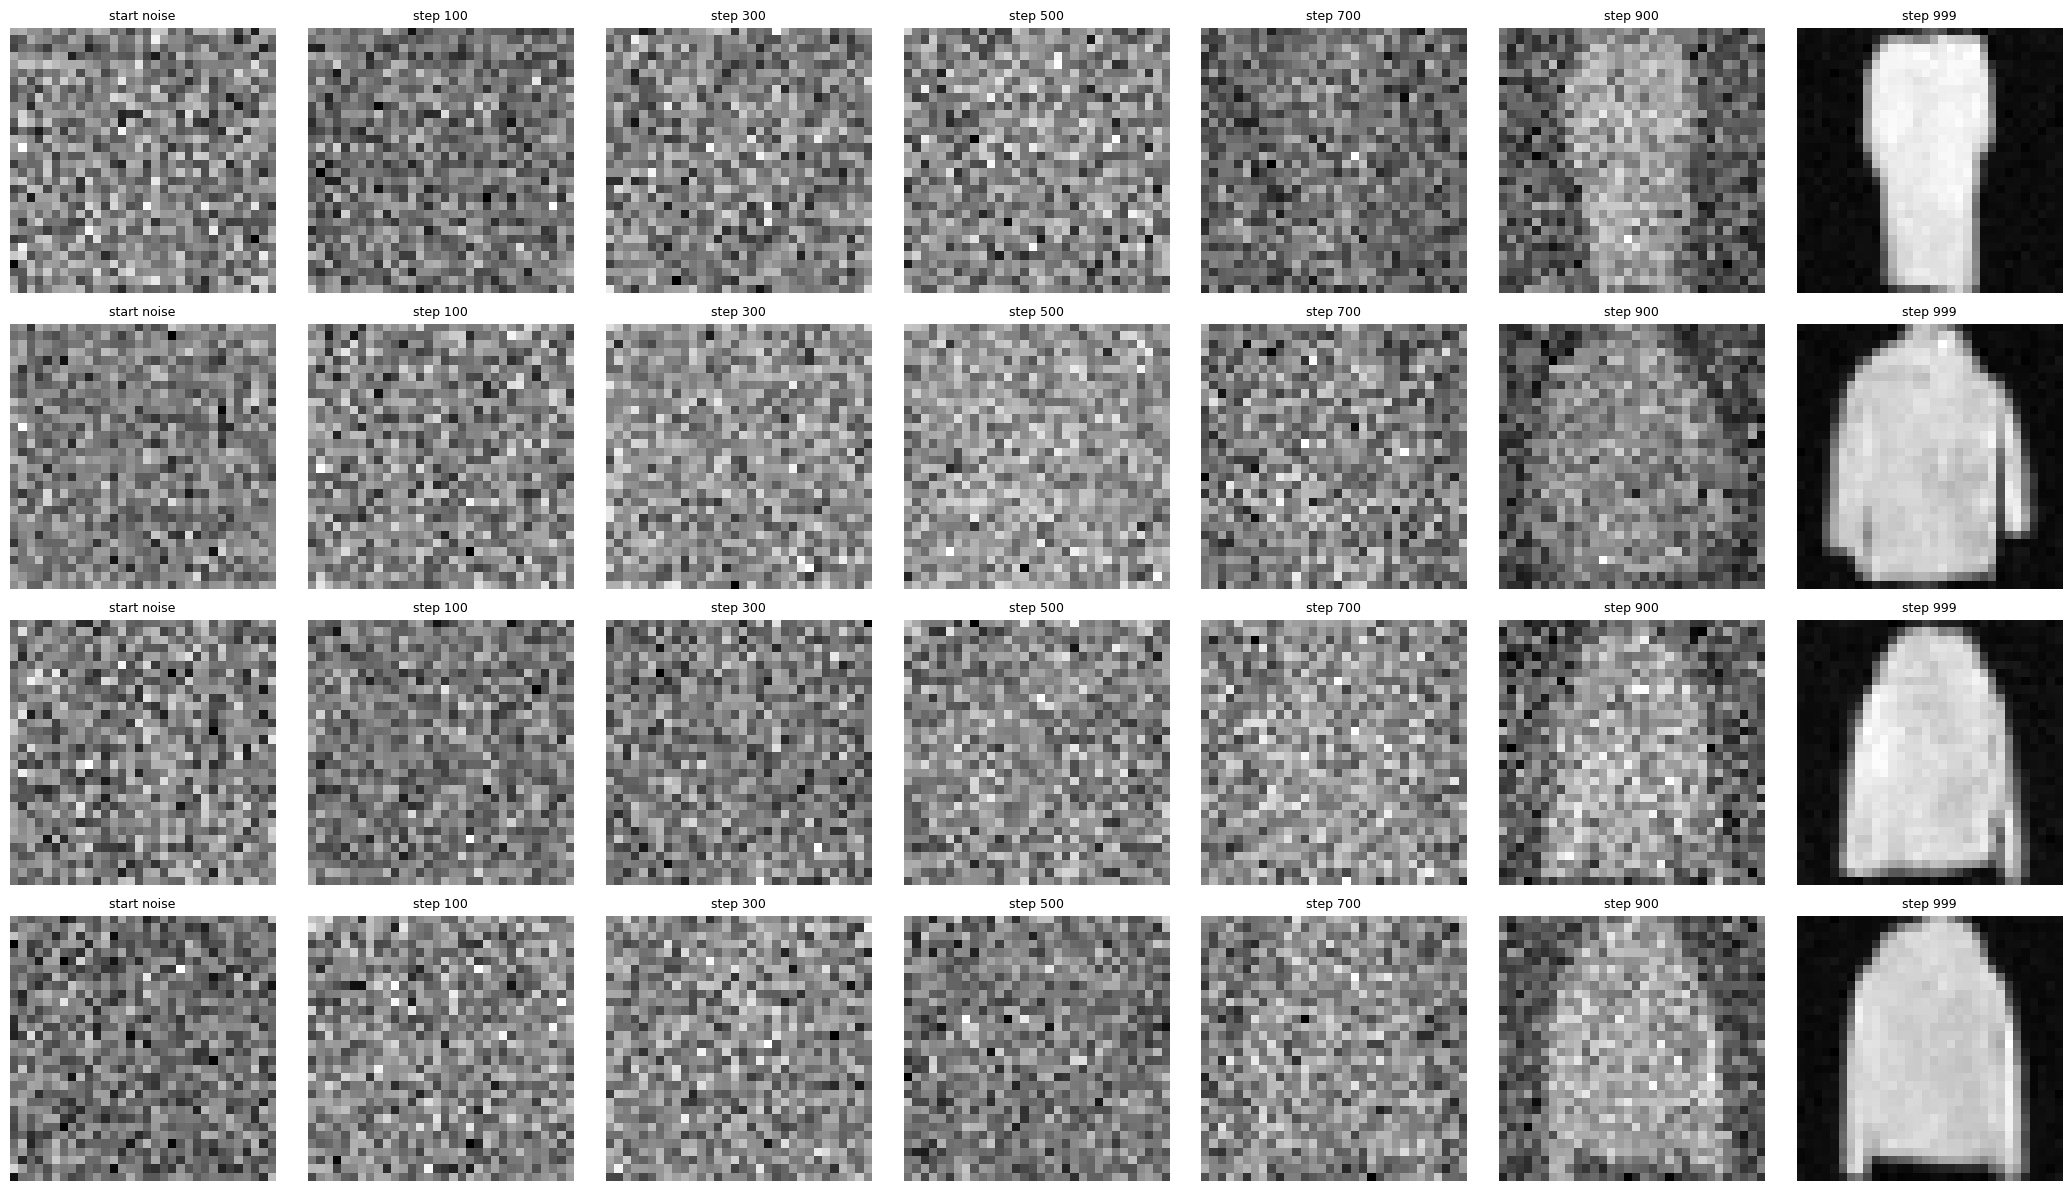

: 

In [ ]:
steps_to_show = [100, 300, 500, 700, 900, 999]
noise = torch.randn(4, 1, args.image_size, args.image_size, device=args.device)
images = trainer.generate_intermediate_samples(
    n_samples=4,
    img_size=args.image_size,
    steps_to_show=steps_to_show,
    n_steps=args.n_steps,
    noise=noise,
    set_seed=True,
)
plot_intermediate_samples(images, steps_to_show, n_samples=4)


## Report question 9: intermediate denoising steps

Use the plots from the previous cell to explain:
- what the earliest reverse steps look like
- when recognizable structure begins to appear
- how local detail is refined near the end of the chain
- how your observations connect to the DDPM reverse-process equations
